In [1]:
!git clone https://github.com/KalesTech/outbreak-analysis.git

Cloning into 'outbreak-analysis'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 48 (delta 15), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (48/48), 32.50 KiB | 1008.00 KiB/s, done.
Resolving deltas: 100% (15/15), done.


# Exploratory Data Analysis (EDA)

This notebook explores the structure and characteristics of a synthetic
outbreak-style time-series dataset. The goal is to understand distributions,
temporal behavior, missing data patterns, and known limitations prior to any
modeling.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

df = pd.read_csv(
    "outbreak-analysis/data/synthetic_outbreak.csv",
    parse_dates=["date"]
)

In [4]:
df.head()

,date,reported_cases,symptom_rate,testing_volume
0,2023-01-01,46.0,NaN,1104.0
1,2023-01-02,49.0,0.301493,1090.0
2,2023-01-03,64.0,0.386873,NaN
3,2023-01-04,73.0,0.285606,1160.0
4,2023-01-05,54.0,0.411784,1148.0


In [5]:
df.tail()

,date,reported_cases,symptom_rate,testing_volume
725,2024-12-26,124.0,0.341519,1461.0
726,2024-12-27,116.0,0.449649,1269.0
727,2024-12-28,113.0,0.419999,NaN
728,2024-12-29,108.0,0.469071,1300.0
729,2024-12-30,NaN,0.453659,NaN


## Dataset Structure and Types

The dataset consists of daily observations with numeric variables for
reported cases, symptom rate, and testing volume. Missing values are present
in multiple columns, reflecting reporting gaps.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            730 non-null    datetime64[ns]
 1   reported_cases  635 non-null    float64       
 2   symptom_rate    639 non-null    float64       
 3   testing_volume  641 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 22.9 KB


## Distribution Analysis

This section examines the distributions of key variables to understand their
scale, spread, and variability.

In [7]:
df.describe()

,date,reported_cases,symptom_rate,testing_volume
count,730,635.000000,639.000000,641.000000
mean,2023-12-31 12:00:00,141.696063,0.447508,1431.903276
min,2023-01-01 00:00:00,30.000000,0.278819,1047.000000
25%,2023-07-02 06:00:00,119.000000,0.404816,1347.000000
50%,2023-12-31 12:00:00,147.000000,0.451410,1446.000000
75%,2024-06-30 18:00:00,173.500000,0.493356,1525.000000
max,2024-12-30 00:00:00,215.000000,0.618803,1718.000000
std,NaN,40.704954,0.064090,129.889737


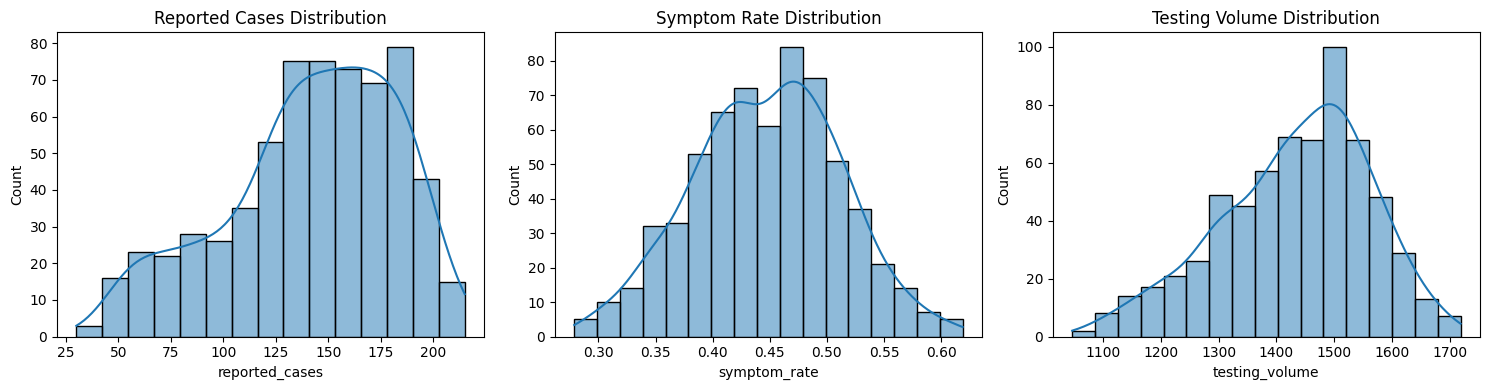

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["reported_cases"], ax=axes[0], kde=True)
axes[0].set_title("Reported Cases Distribution")

sns.histplot(df["symptom_rate"], ax=axes[1], kde=True)
axes[1].set_title("Symptom Rate Distribution")

sns.histplot(df["testing_volume"], ax=axes[2], kde=True)
axes[2].set_title("Testing Volume Distribution")

plt.tight_layout()
plt.show()

## Temporal Trends

The following visualization illustrates how reported cases evolve over time.

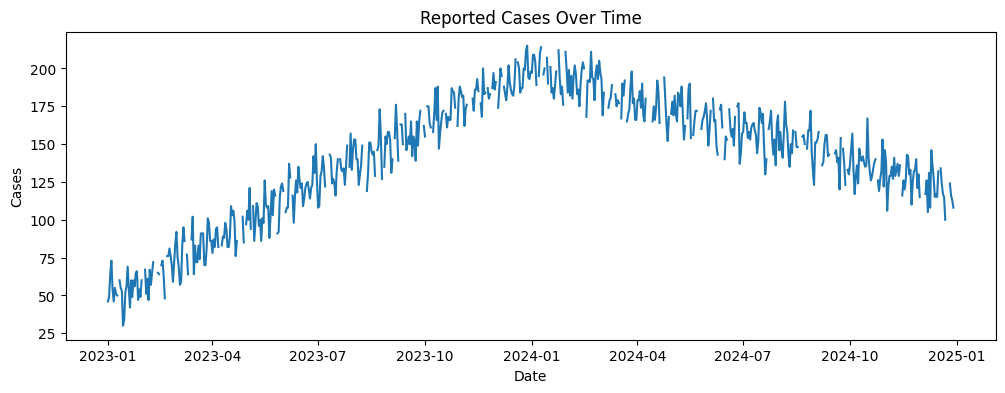

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["reported_cases"])
plt.title("Reported Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.show()

Reported cases exhibit a rise-and-fall pattern consistent with a single
outbreak wave, though noise and missing observations are visible.

## Moving Average Smoothing

A rolling mean is used to smooth short-term variability and highlight
longer-term trends.

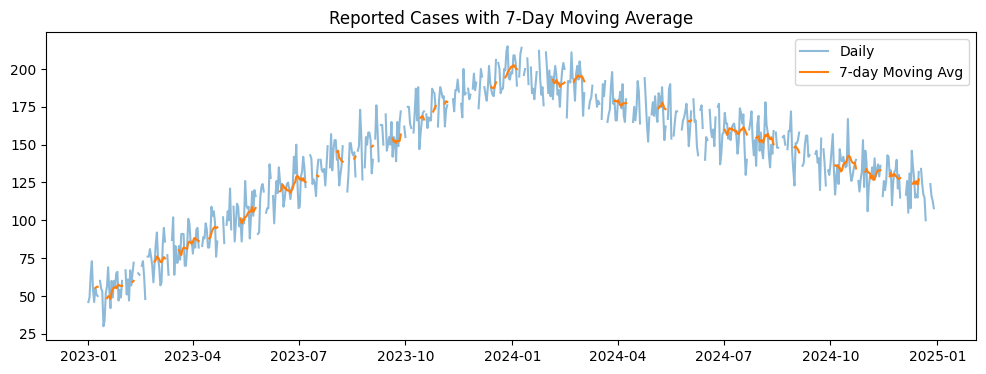

In [10]:
df["reported_cases_ma7"] = df["reported_cases"].rolling(window=7).mean()

plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["reported_cases"], alpha=0.5, label="Daily")
plt.plot(df["date"], df["reported_cases_ma7"], label="7-day Moving Avg")
plt.legend()
plt.title("Reported Cases with 7-Day Moving Average")
plt.show()

## Missing Data Analysis

This section evaluates the extent and pattern of missing values in the dataset.

In [11]:
df.isna().mean()

,0
date,0.000000
reported_cases,0.130137
symptom_rate,0.124658
testing_volume,0.121918
reported_cases_ma7,0.626027


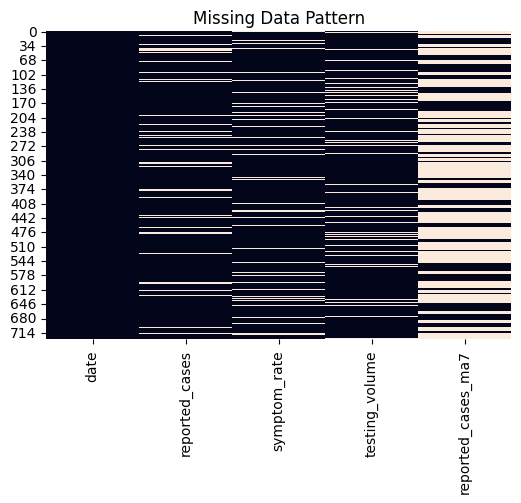

In [12]:
plt.figure(figsize=(6, 4))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing Data Pattern")
plt.show()

Missing values are present in both reported cases and symptom rate. The
missingness appears sporadic rather than clustered, suggesting reporting gaps
rather than systemic outages.

## Observations and Potential Anomalies

- Sudden spikes in reported cases may reflect reporting delays rather than
  true increases in infections.
- Symptom rate appears noisier than case counts, consistent with
  self-reported or survey-based data.
- Testing volume varies independently of case counts, which may introduce
  bias when interpreting observed trends.

## Dataset Limitations

- The dataset is synthetic and simplified, limiting real-world validity.
- Small sample size reduces statistical power.
- No ground-truth infection signal is available.
- Temporal autocorrelation is partly an artifact of construction.

These limitations should be considered when interpreting downstream modeling
results.